# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1) What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

the intuition of adding a penalty to mwan squared error that grows in the size makes the model pay for complexity.it has to jusify its increase coefficient magnitude. It discourages overfitting.

How does regularization provide a way of exploring the bias-variance trade-off?


2) The regularization provides a way of exploring bias-variance trade-off by adding the absolute value penalty or squared penalty & charges the model lambda for each unit of coefficeint or squared-unit of coefficient it wants to purchase. The model will then pick more predictable variables and reduce the size of the coefficients, which will result in more interpretable and reliable models that can further explore bias-variance trade-off.
3) The difference between LASSO and Ridge Regression is that LASSO sends coefs to zero and lambda increases. This leads it to remove variables from the model, and it will select a model specification for you. Meanwhile Ridge will shrink all the coefficients toward zero. Ths leads to it never removing a variable completely. The LASSO penalty also has points of non-differentiaability at zero or corners. Because of this, LASSO "zeros out" variables and selects a specific model. The Ridge penalty os smooth as zero, and it increases faster than the |b_l|. The ridge smoothly shrinks all its coefficients toward zero. Ridge has better performance, while LASSO has more interpretable results.

4) We typically scale variables for use in regularized regression by looking at the cost function. This makes you compare your variables indirectly by considering which ones have the most explanatory power on the margin. When changing the variable scale you can artifically boost this comparison. Z-score normalization is used it subtratcs the mean and divide by SD.
5) Penalty lambda is typically selected by first picking a grid of lambda values. For each of these values, use k-fCV. Afterwards, you pick the mean/median value of MSE(b) for that lambda. Finally, you pick the lambda that the mean/median value of MSE(b) across the grid.
6) No, we do not include the penalty term when evaluating cross-validated MSE. It is not used because it only is part of the objective function that is used during model fitting—it guides which coefficients we choose during the time we are training the model. When we look at the model on data, we only care about how well it actually predicts the output we are looking for.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

1) Import the cars_hw.csv dataset. Create an Age variable for each vehicle. Take Mileage_Run and Age, and (a) use PolynomialFeatures to create a third degree expansion, (b) use StandardScaler to  z -score normalize them.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [3]:
#defining functions
mse = lambda y_test, y_hat: np.sum((y_test - y_hat) ** 2) / len(y_hat)
z_score = lambda x: (x - x.mean()) / x.std()

In [5]:
#loading dataset
df = pd.read_csv('cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [6]:
# Create Age variable
current_year = 2026
df['Age'] = current_year - df['Make_Year']

# Select features for analysis
features = ['Mileage_Run', 'Age']
X = df[features].copy()
y = df['Price']

In [7]:
#Using Polynomial features to create a third degree expansion
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out(features)

In [8]:
# Use StandardScaler to z-score normalize them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Convert to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=poly_names)

2) Use your features, run linear regression. What is the sign for the interaction between Mileage_Run and Age?

In [13]:
# Fit linear regression on standardized polynomial features
lr_model = LinearRegression()
lr_model.fit(X_scaled, y)

# Display all coefficients
coef_df = pd.DataFrame({
    'Feature': poly_names,
    'Coefficient': lr_model.coef_
})
# Find the sign for the interaction between Mileage_Run and Age
interaction_term = 'Mileage_Run Age'
interaction_idx = np.where(poly_names == interaction_term)[0][0]
interaction_coef = lr_model.coef_[interaction_idx]

# R-squared score
r2_score = lr_model.score(X_scaled, y)
print(f"\nLinear Regression R²: {r2_score}")


Linear Regression R²: 0.3398062530145276


Use LassoCV to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid alphas = np.logspace(1,3,20) to find the cost parameter)

In [18]:
# Create alpha grid and LassoCV model
alpha_grid = np.logspace(1, 3, 20)  \
# Fit LassoCV with 20-fold cross-validation
lasso_cv = LassoCV(
    alphas=alpha_grid,
    cv=20,
    random_state=100,
    max_iter=10000
)
lasso_cv.fit(X_scaled, y)
# Find optimal alpha
index_star = np.argmin(np.median(lasso_cv.mse_path_, axis=1))
alpha_star = lasso_cv.alphas_[index_star]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 22977691506.578125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 598283106767.5625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 850706961927.5469, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objec

4) Plot the cross-validated MSE by  α .

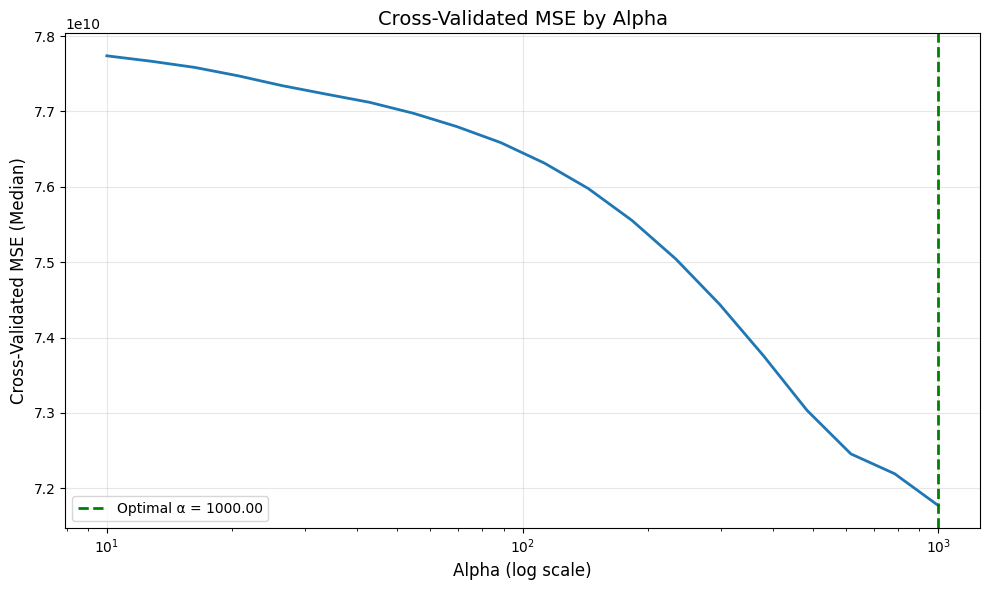

Optimal cost hyperparameter: 1000.0000


In [19]:
plt.figure(figsize=(10, 6))

# Plot median MSE across folds
median_mse = np.median(lasso_cv.mse_path_, axis=1)
sns.lineplot(x=lasso_cv.alphas_, y=median_mse, linewidth=2)

# Add vertical line at optimal alpha
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=2,
            label=f'Optimal α = {alpha_star:.2f}')

plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Cross-Validated MSE (Median)', fontsize=12)
plt.title('Cross-Validated MSE by Alpha', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal cost hyperparameter: {alpha_star:.4f}")

Plot the coefficient paths by  α .

In [20]:
# Generate coefficient paths
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)
print(f"Coefficient paths shape: {coefs.shape}")
print(f"  - {coefs.shape[0]} alpha values")
print(f"  - {coefs.shape[1]} features")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.410e+10, tolerance: 1.316e

Coefficient paths shape: (20, 9)
  - 20 alpha values
  - 9 features


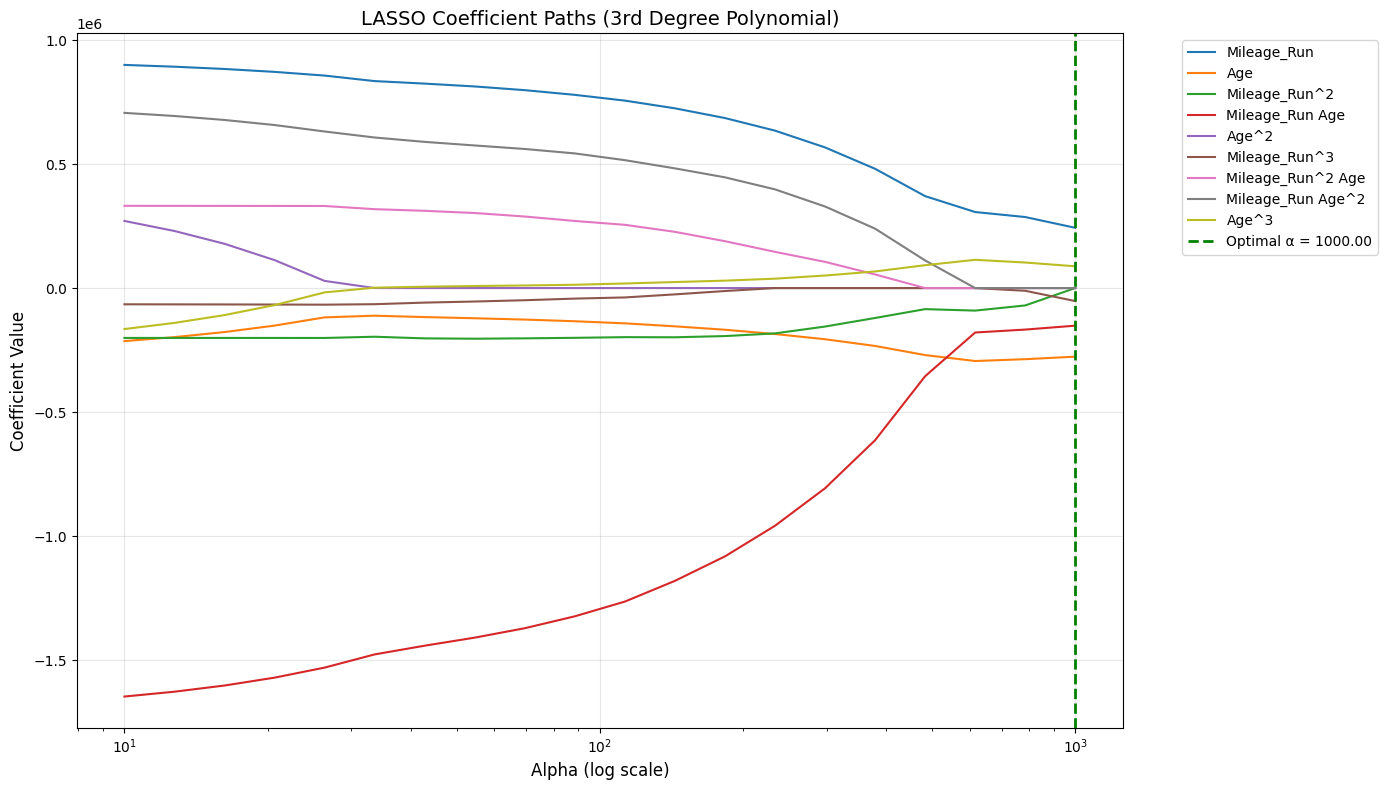

In [21]:
plt.figure(figsize=(14, 8))

# Plot coefficient paths for all features
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i], linewidth=1.5)

# Add vertical line at optimal alpha
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=2,
            label=f'Optimal α = {alpha_star:.2f}')

plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('LASSO Coefficient Paths (3rd Degree Polynomial)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Which features are actually selected? What proportion are set equal to zero?

In [22]:
# Fit LASSO at optimal alpha
optimal_lasso = Lasso(alpha=alpha_star, max_iter=10000)
optimal_lasso.fit(X_scaled, y)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Feature': poly_names,
    'Linear_Regression': lr_model.coef_,
    'LASSO_Optimal': optimal_lasso.coef_
})

# Identify zero coefficients (threshold for numerical precision)
threshold = 1e-6
comparison_df['Is_Zero'] = np.abs(comparison_df['LASSO_Optimal']) < threshold

# Count statistics
n_features = len(comparison_df)
n_zero = comparison_df['Is_Zero'].sum()
n_nonzero = n_features - n_zero

print(f"{'='*60}")
print("FEATURE SELECTION ANALYSIS")
print(f"{'='*60}")
print(f"Total features: {n_features}")
print(f"Features selected (non-zero): {n_nonzero}")
print(f"Features eliminated (zero): {n_zero}")
print(f"Proportion set to zero: {n_zero/n_features:.2%}")
print(f"{'='*60}")

print("\nSELECTED FEATURES (Non-zero coefficients):")
selected = comparison_df[~comparison_df['Is_Zero']].sort_values('LASSO_Optimal', key=abs, ascending=False)
print(selected[['Feature', 'LASSO_Optimal']].to_string(index=False))

print("\nELIMINATED FEATURES (Zero coefficients):")
eliminated = comparison_df[comparison_df['Is_Zero']]
print(eliminated['Feature'].tolist())

FEATURE SELECTION ANALYSIS
Total features: 9
Features selected (non-zero): 5
Features eliminated (zero): 4
Proportion set to zero: 44.44%

SELECTED FEATURES (Non-zero coefficients):
        Feature  LASSO_Optimal
            Age -276500.895776
    Mileage_Run  242953.216388
Mileage_Run Age -151598.545767
          Age^3   87796.740706
  Mileage_Run^3  -52410.347536

ELIMINATED FEATURES (Zero coefficients):
['Mileage_Run^2', 'Age^2', 'Mileage_Run^2 Age', 'Mileage_Run Age^2']


Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [23]:
# Add comparison metrics
comparison_df['Abs_LR'] = np.abs(comparison_df['Linear_Regression'])
comparison_df['Abs_LASSO'] = np.abs(comparison_df['LASSO_Optimal'])
comparison_df['Magnitude_Change'] = comparison_df['Abs_LASSO'] - comparison_df['Abs_LR']
comparison_df['Increased'] = (comparison_df['Abs_LASSO'] > comparison_df['Abs_LR']) & (~comparison_df['Is_Zero'])

# Check for sign changes (only for non-zero LASSO coefficients)
comparison_df['LR_Sign'] = np.sign(comparison_df['Linear_Regression'])
comparison_df['LASSO_Sign'] = np.sign(comparison_df['LASSO_Optimal'])
comparison_df['Sign_Changed'] = (comparison_df['LR_Sign'] != comparison_df['LASSO_Sign']) & (~comparison_df['Is_Zero'])

print(f"{'='*60}")
print("COEFFICIENT COMPARISON: Linear Regression vs LASSO")
print(f"{'='*60}")

# Coefficients that increased in magnitude
increased = comparison_df[comparison_df['Increased']]
print(f"\nCoefficients that INCREASED in magnitude ({len(increased)} features):")
if len(increased) > 0:
    print(increased[['Feature', 'Linear_Regression', 'LASSO_Optimal', 'Magnitude_Change']].to_string(index=False))
else:
    print("  None")

# Coefficients that changed sign
sign_changed = comparison_df[comparison_df['Sign_Changed']]
print(f"\nCoefficients that CHANGED SIGN ({len(sign_changed)} features):")
if len(sign_changed) > 0:
    print(sign_changed[['Feature', 'Linear_Regression', 'LASSO_Optimal']].to_string(index=False))
else:
    print("  None")

# Full comparison table
print("\nFull Comparison Table:")
print(comparison_df[['Feature', 'Linear_Regression', 'LASSO_Optimal', 'Is_Zero']].to_string(index=False))

COEFFICIENT COMPARISON: Linear Regression vs LASSO

Coefficients that INCREASED in magnitude (1 features):
Feature  Linear_Regression  LASSO_Optimal  Magnitude_Change
    Age     -248172.185538 -276500.895776      28328.710238

Coefficients that CHANGED SIGN (1 features):
Feature  Linear_Regression  LASSO_Optimal
  Age^3     -210037.887636   87796.740706

Full Comparison Table:
          Feature  Linear_Regression  LASSO_Optimal  Is_Zero
      Mileage_Run       9.117748e+05  242953.216388    False
              Age      -2.481722e+05 -276500.895776    False
    Mileage_Run^2      -2.072926e+05      -0.000000     True
  Mileage_Run Age      -1.671212e+06 -151598.545767    False
            Age^2       3.505507e+05      -0.000000     True
    Mileage_Run^3      -6.514490e+04  -52410.347536    False
Mileage_Run^2 Age       3.388195e+05      -0.000000     True
Mileage_Run Age^2       7.167816e+05      -0.000000     True
            Age^3      -2.100379e+05   87796.740706    False


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

1) Import the heart_failure_clinical_records_dataset.csv dataset. Use PolynomialFeatures to create a third-degree expansion of age, ejection_fraction, and serum_creatinine, and then use StandardScaler to  z -score normalize your results. Use PolynomialFeatures with interaction_only=True to interact the dummy/categorical variables anaemia, diabetes, high_blood_pressure, and smoking. Concatenate these results into your feature/covariate matrix.

In [24]:
#defining functions to start
mse = lambda y_test, y_hat: np.sum((y_test - y_hat) ** 2) / len(y_hat)
z_score = lambda x: (x - x.mean()) / x.std()

In [25]:
#loading data
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [26]:
# Select continuous features for polynomial expansion
continuous_features = ['age', 'ejection_fraction', 'serum_creatinine']
X_continuous = df[continuous_features].copy()

# Use PolynomialFeatures to create a third-degree expansion
poly_cont = PolynomialFeatures(degree=3, include_bias=False)
X_poly_cont = poly_cont.fit_transform(X_continuous)
poly_cont_names = poly_cont.get_feature_names_out(continuous_features)


In [29]:
# Select categorical/dummy features
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_categorical = df[categorical_features].copy()

# Use PolynomialFeatures with interaction_only=True for categorical variables
poly_cat = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_poly_cat = poly_cat.fit_transform(X_categorical)
poly_cat_names = poly_cat.get_feature_names_out(categorical_features)

Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

In [30]:
# Concatenate polynomial continuous features with categorical interactions
X_combined = np.hstack([X_poly_cont, X_poly_cat])
all_feature_names = np.concatenate([poly_cont_names, poly_cat_names])
# Target variable
y = df['DEATH_EVENT']

# Use StandardScaler to z-score normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# Convert to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=all_feature_names)


In [32]:
# Fit linear regression on standardized features
lr_model = LinearRegression()
lr_model.fit(X_scaled, y)

# Display all coefficients
coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
# Check age specifically
age_coef = lr_model.coef_[np.where(all_feature_names == 'age')[0][0]]
ef_coef = lr_model.coef_[np.where(all_feature_names == 'ejection_fraction')[0][0]]
creat_coef = lr_model.coef_[np.where(all_feature_names == 'serum_creatinine')[0][0]]
# R-squared score
r2_score = lr_model.score(X_scaled, y)
print(f"\nLinear Regression R²: {r2_score:.4f}")


Linear Regression R²: 0.3588


3) Use LassoCV to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid alphas = np.logspace(-5,5,30) to find the cost parameter)
Plot the cross-validated MSE by  α .

In [33]:
# Create alpha grid and LassoCV model
alpha_grid = np.logspace(-5, 5, 30)  # Wide range from 10^-5 to 10^5
print(f"Alpha grid: {len(alpha_grid)} values from {alpha_grid[0]:.2e} to {alpha_grid[-1]:.2e}")

# Fit LassoCV with 20-fold cross-validation
lasso_cv = LassoCV(
    alphas=alpha_grid,
    cv=20,
    random_state=100,
    max_iter=10000
)
lasso_cv.fit(X_scaled, y)

# Find optimal alpha (using median MSE across folds)
index_star = np.argmin(np.median(lasso_cv.mse_path_, axis=1))
alpha_star = lasso_cv.alphas_[index_star]

print(f"\n{'='*50}")
print(f"OPTIMAL ALPHA: {alpha_star:.6f}")
print(f"Minimum Cross-Validated MSE: {np.min(np.median(lasso_cv.mse_path_, axis=1)):.4f}")
print(f"{'='*50}")

Alpha grid: 30 values from 1.00e-05 to 1.00e+05


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1571131221602329, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.0211058802483066, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.9557016170357215, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co


OPTIMAL ALPHA: 0.012690
Minimum Cross-Validated MSE: 0.1382


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.8255466281275545, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.7244766617853102, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.822671897121349, tolerance: 0.006354929577464795
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

Plot the cross-validated MSE by  α .

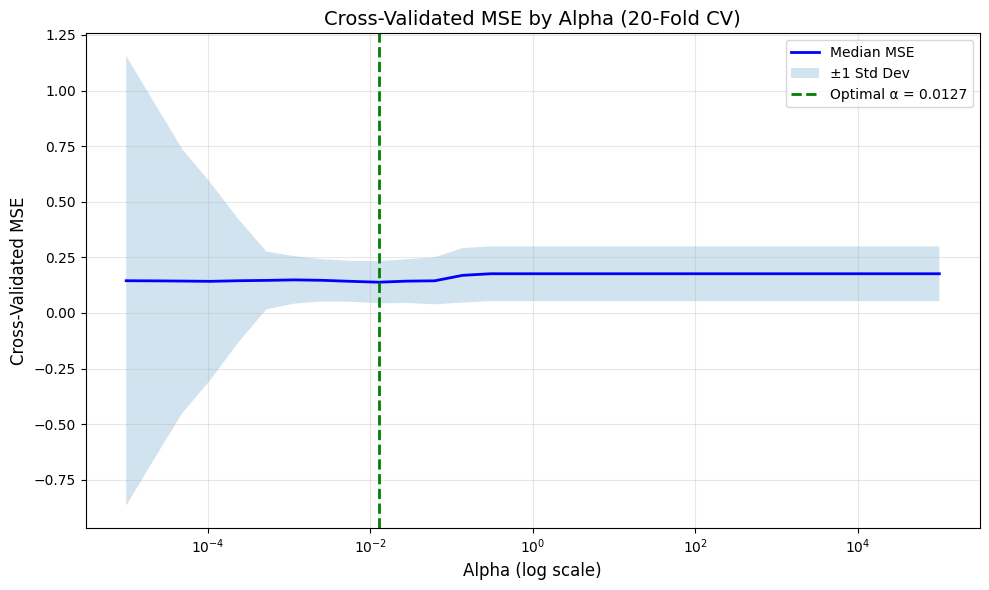

Optimal cost hyperparameter: 0.012690


In [35]:
plt.figure(figsize=(10, 6))

# Plot median MSE across folds with error bands
median_mse = np.median(lasso_cv.mse_path_, axis=1)
std_mse = np.std(lasso_cv.mse_path_, axis=1)

plt.semilogx(lasso_cv.alphas_, median_mse, 'b-', linewidth=2, label='Median MSE')
plt.fill_between(lasso_cv.alphas_,
                  median_mse - std_mse,
                  median_mse + std_mse,
                  alpha=0.2, label='±1 Std Dev')

# Add vertical line at optimal alpha
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=2,
            label=f'Optimal α = {alpha_star:.4f}')

plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Cross-Validated MSE', fontsize=12)
plt.title('Cross-Validated MSE by Alpha (20-Fold CV)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal cost hyperparameter: {alpha_star:.6f}")

Plot the coefficient paths by  α .

In [36]:
# Generate coefficient paths
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)
print(f"Coefficient paths shape: {coefs.shape}")
print(f"  - {coefs.shape[0]} alpha values")
print(f"  - {coefs.shape[1]} features")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

Coefficient paths shape: (30, 29)
  - 30 alpha values
  - 29 features


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.575e+00, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.369e-01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(


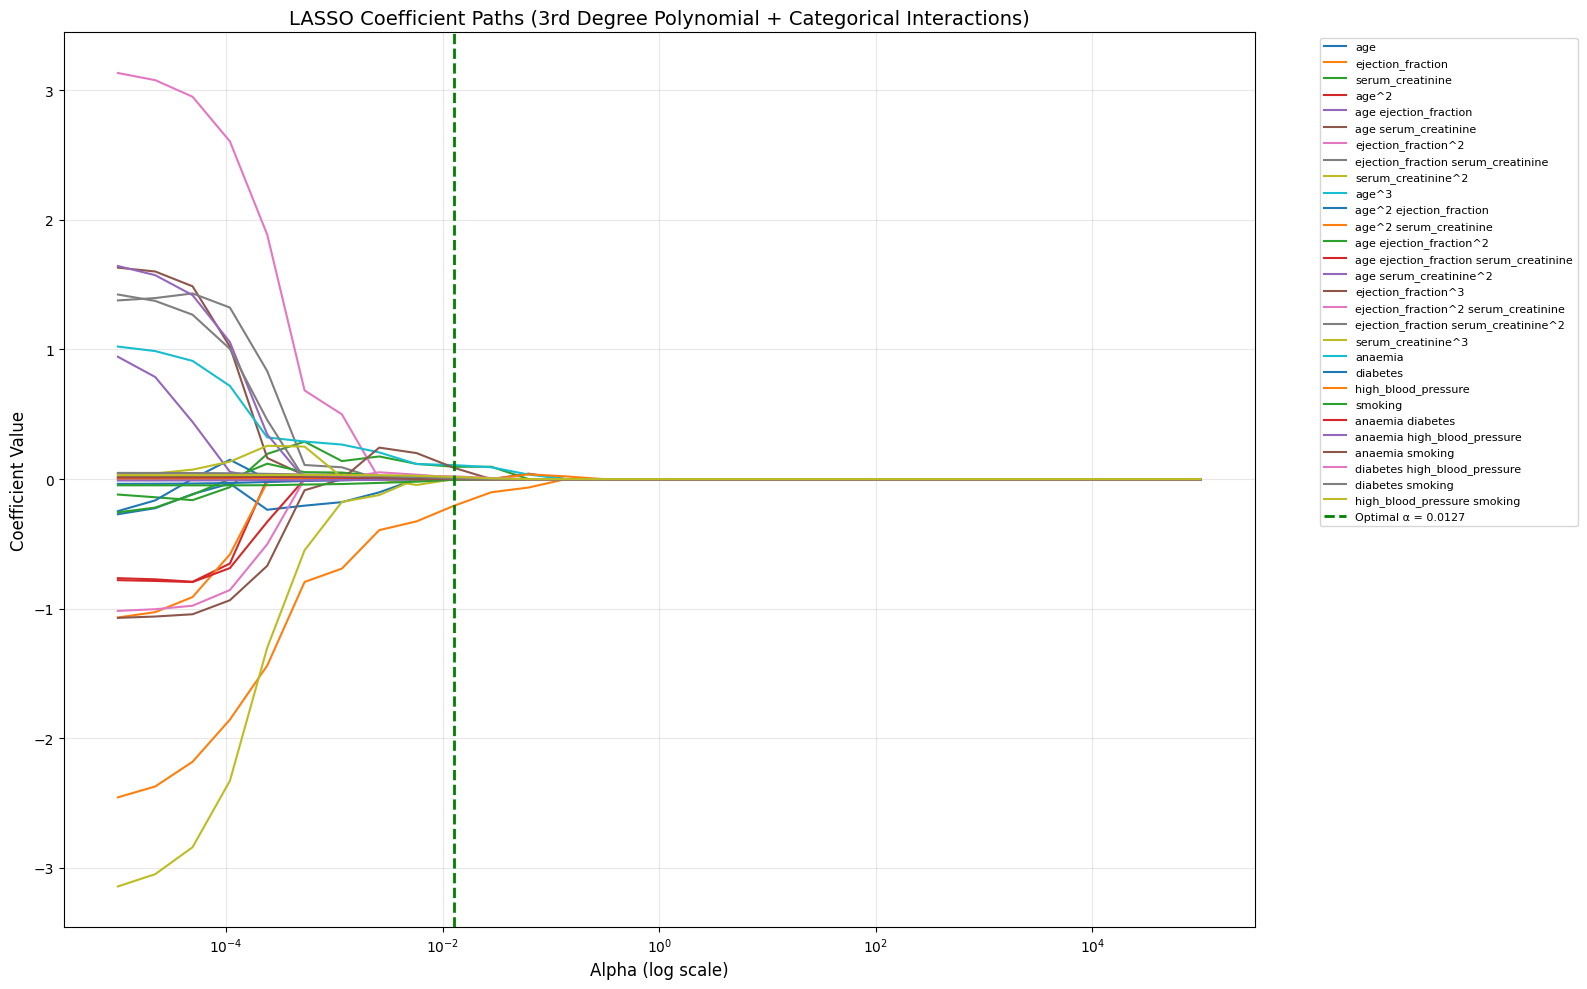

In [37]:
plt.figure(figsize=(16, 10))

# Plot coefficient paths for all features
for i in range(coefs.shape[1]):
    plt.semilogx(alpha_grid, coefs[:, i], label=all_feature_names[i], linewidth=1.5)

# Add vertical line at optimal alpha
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=2,
            label=f'Optimal α = {alpha_star:.4f}')

plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('LASSO Coefficient Paths (3rd Degree Polynomial + Categorical Interactions)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

ANSWER

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

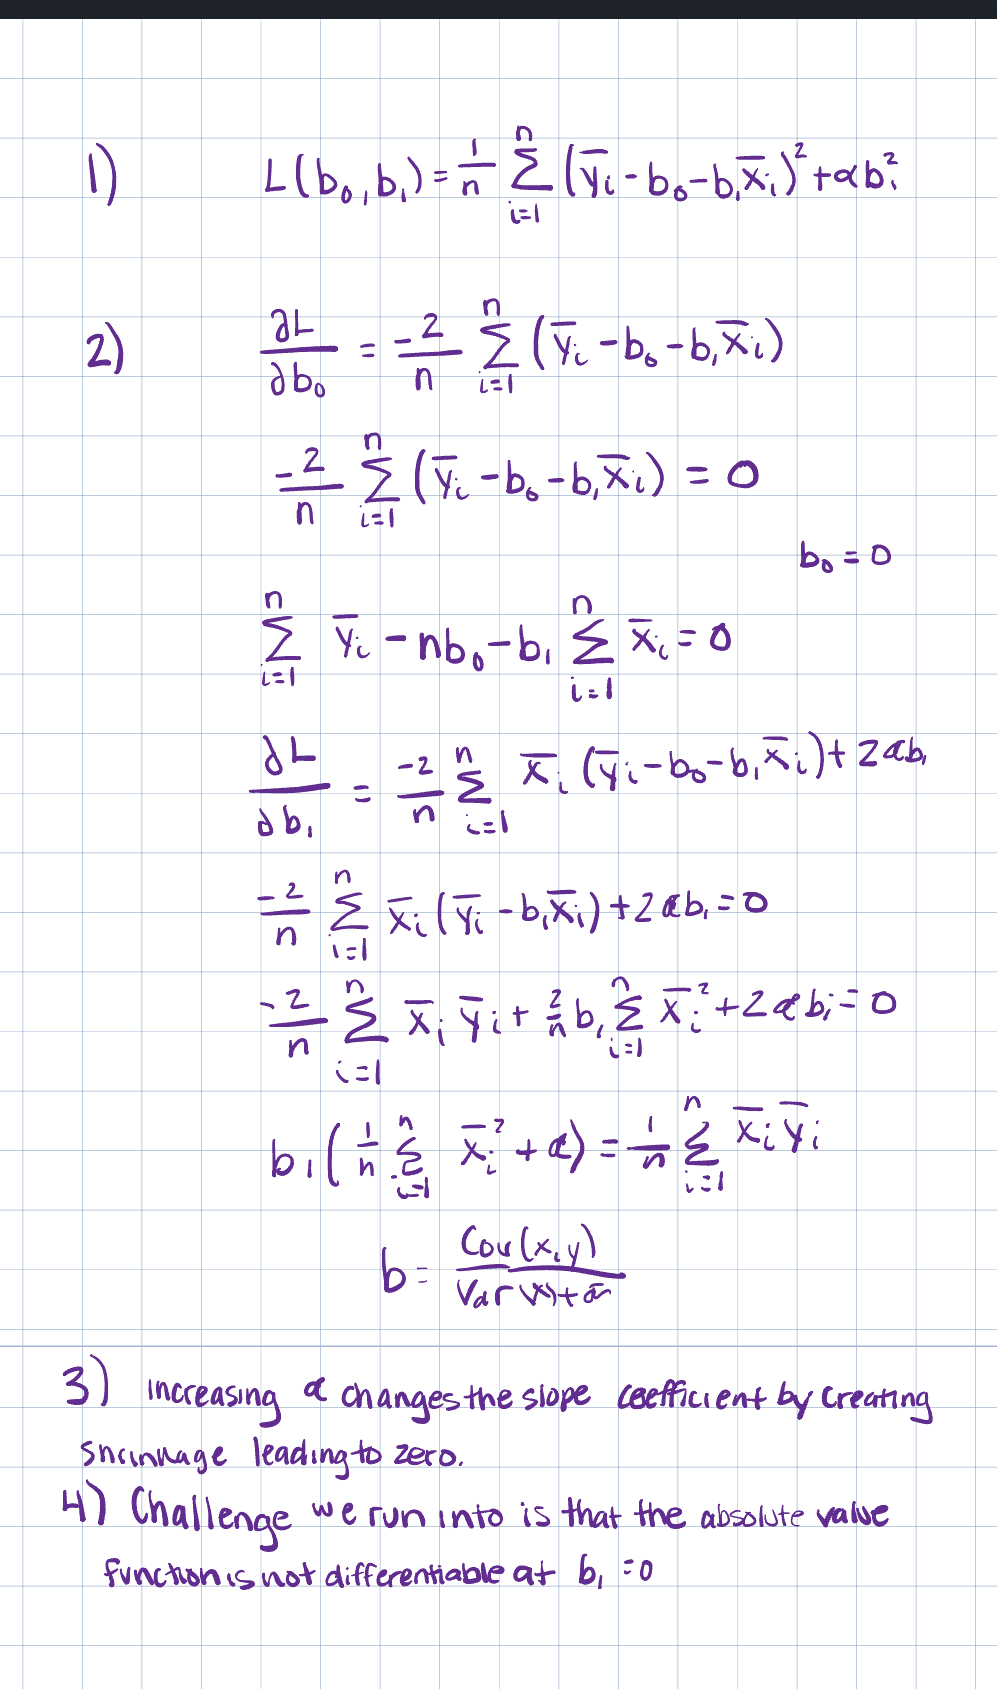

In [39]:
from IPython.display import Image
Image('/content/IMG_0591.jpg') # Replace with your filename